In [4]:
!pip install yellowbrick
from sklearn.preprocessing import Normalizer
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv("sales_data_sample.csv", encoding='latin1')


In [8]:
df.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


In [10]:
df.dtypes

ORDERNUMBER           int64
QUANTITYORDERED       int64
PRICEEACH           float64
ORDERLINENUMBER       int64
SALES               float64
ORDERDATE            object
STATUS               object
QTR_ID                int64
MONTH_ID              int64
YEAR_ID               int64
PRODUCTLINE          object
MSRP                  int64
PRODUCTCODE          object
CUSTOMERNAME         object
PHONE                object
ADDRESSLINE1         object
ADDRESSLINE2         object
CITY                 object
STATE                object
POSTALCODE           object
COUNTRY              object
TERRITORY            object
CONTACTLASTNAME      object
CONTACTFIRSTNAME     object
DEALSIZE             object
dtype: object

In [12]:
df.isnull().sum()

ORDERNUMBER            0
QUANTITYORDERED        0
PRICEEACH              0
ORDERLINENUMBER        0
SALES                  0
ORDERDATE              0
STATUS                 0
QTR_ID                 0
MONTH_ID               0
YEAR_ID                0
PRODUCTLINE            0
MSRP                   0
PRODUCTCODE            0
CUSTOMERNAME           0
PHONE                  0
ADDRESSLINE1           0
ADDRESSLINE2        2521
CITY                   0
STATE               1486
POSTALCODE            76
COUNTRY                0
TERRITORY           1074
CONTACTLASTNAME        0
CONTACTFIRSTNAME       0
DEALSIZE               0
dtype: int64

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDERNUMBER       2823 non-null   int64  
 1   QUANTITYORDERED   2823 non-null   int64  
 2   PRICEEACH         2823 non-null   float64
 3   ORDERLINENUMBER   2823 non-null   int64  
 4   SALES             2823 non-null   float64
 5   ORDERDATE         2823 non-null   object 
 6   STATUS            2823 non-null   object 
 7   QTR_ID            2823 non-null   int64  
 8   MONTH_ID          2823 non-null   int64  
 9   YEAR_ID           2823 non-null   int64  
 10  PRODUCTLINE       2823 non-null   object 
 11  MSRP              2823 non-null   int64  
 12  PRODUCTCODE       2823 non-null   object 
 13  CUSTOMERNAME      2823 non-null   object 
 14  PHONE             2823 non-null   object 
 15  ADDRESSLINE1      2823 non-null   object 
 16  ADDRESSLINE2      302 non-null    object 


In [16]:
plt.figure(figsize=(30, 26))

<Figure size 3000x2600 with 0 Axes>

<Figure size 3000x2600 with 0 Axes>

<Axes: >

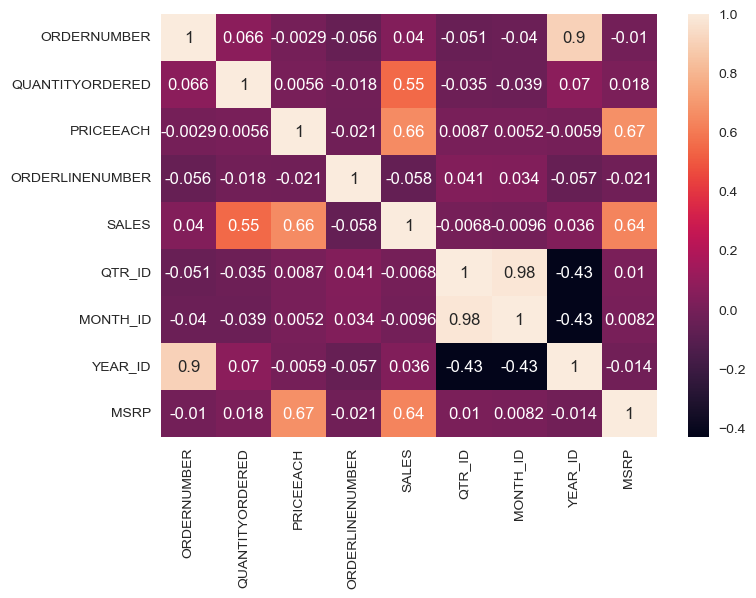

In [18]:
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True)


In [20]:
df_drop = ['ADDRESSLINE1', 'ADDRESSLINE2', 'STATUS', 'POSTALCODE', 'CITY',
           'TERRITORY', 'PHONE', 'STATE', 'CONTACTFIRSTNAME', 'CONTACTLASTNAME',
           'CUSTOMERNAME', 'ORDERNUMBER']

In [22]:
df = df.drop(df_drop, axis=1)

In [24]:
df.head()

,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,QTR_ID,MONTH_ID,YEAR_ID,PRODUCTLINE,MSRP,PRODUCTCODE,COUNTRY,DEALSIZE
0,30,95.70,2,2871.00,2/24/2003 0:00,1,2,2003,Motorcycles,95,S10_1678,USA,Small
1,34,81.35,5,2765.90,5/7/2003 0:00,2,5,2003,Motorcycles,95,S10_1678,France,Small
2,41,94.74,2,3884.34,7/1/2003 0:00,3,7,2003,Motorcycles,95,S10_1678,France,Medium
3,45,83.26,6,3746.70,8/25/2003 0:00,3,8,2003,Motorcycles,95,S10_1678,USA,Medium
4,49,100.00,14,5205.27,10/10/2003 0:00,4,10,2003,Motorcycles,95,S10_1678,USA,Medium


In [26]:
df.shape

(2823, 13)

In [28]:
df.isnull().sum()

QUANTITYORDERED    0
PRICEEACH          0
ORDERLINENUMBER    0
SALES              0
ORDERDATE          0
QTR_ID             0
MONTH_ID           0
YEAR_ID            0
PRODUCTLINE        0
MSRP               0
PRODUCTCODE        0
COUNTRY            0
DEALSIZE           0
dtype: int64

In [30]:
df.dtypes

QUANTITYORDERED      int64
PRICEEACH          float64
ORDERLINENUMBER      int64
SALES              float64
ORDERDATE           object
QTR_ID               int64
MONTH_ID             int64
YEAR_ID              int64
PRODUCTLINE         object
MSRP                 int64
PRODUCTCODE         object
COUNTRY             object
DEALSIZE            object
dtype: object

In [32]:
country = pd.get_dummies(df['COUNTRY'])

In [34]:
productline = pd.get_dummies(df['PRODUCTLINE'])

In [36]:
Dealsize = pd.get_dummies(df['DEALSIZE'])

In [38]:
df = pd.concat([df, country, productline, Dealsize], axis=1)

In [40]:
df.head()

,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,QTR_ID,MONTH_ID,YEAR_ID,PRODUCTLINE,MSRP,...,Classic Cars,Motorcycles,Planes,Ships,Trains,Trucks and Buses,Vintage Cars,Large,Medium,Small
0,30,95.70,2,2871.00,2/24/2003 0:00,1,2,2003,Motorcycles,95,...,False,True,False,False,False,False,False,False,False,True
1,34,81.35,5,2765.90,5/7/2003 0:00,2,5,2003,Motorcycles,95,...,False,True,False,False,False,False,False,False,False,True
2,41,94.74,2,3884.34,7/1/2003 0:00,3,7,2003,Motorcycles,95,...,False,True,False,False,False,False,False,False,True,False
3,45,83.26,6,3746.70,8/25/2003 0:00,3,8,2003,Motorcycles,95,...,False,True,False,False,False,False,False,False,True,False
4,49,100.00,14,5205.27,10/10/2003 0:00,4,10,2003,Motorcycles,95,...,False,True,False,False,False,False,False,False,True,False


In [42]:
df_drop = ['COUNTRY', 'PRODUCTLINE', 'DEALSIZE']

In [44]:
df = df.drop(df_drop, axis=1)

In [46]:
df.dtypes

QUANTITYORDERED       int64
PRICEEACH           float64
ORDERLINENUMBER       int64
SALES               float64
ORDERDATE            object
QTR_ID                int64
MONTH_ID              int64
YEAR_ID               int64
MSRP                  int64
PRODUCTCODE          object
Australia              bool
Austria                bool
Belgium                bool
Canada                 bool
Denmark                bool
Finland                bool
France                 bool
Germany                bool
Ireland                bool
Italy                  bool
Japan                  bool
Norway                 bool
Philippines            bool
Singapore              bool
Spain                  bool
Sweden                 bool
Switzerland            bool
UK                     bool
USA                    bool
Classic Cars           bool
Motorcycles            bool
Planes                 bool
Ships                  bool
Trains                 bool
Trucks and Buses       bool
Vintage Cars        

In [48]:
WCSS = []  # Withhin Cluster Sum of Squares from the centroid

In [50]:
df = df.select_dtypes(include=['number'])


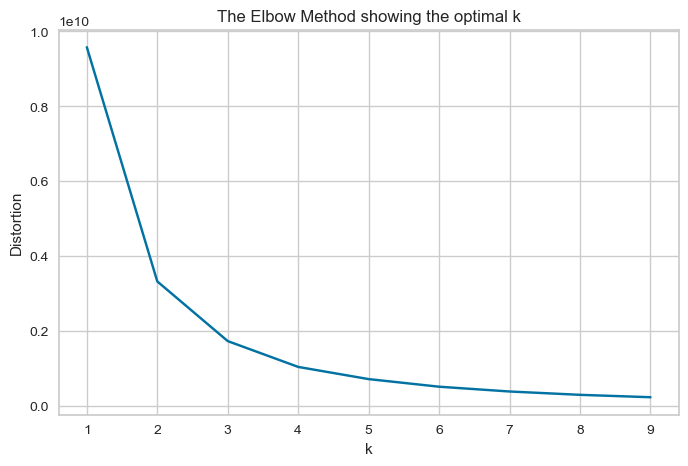

In [52]:
distortions = []
K = range(1, 10)
for k in K:
    kmeanModel = KMeans(n_clusters=k, random_state=42)
    kmeanModel.fit(df)
    distortions.append(kmeanModel.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K, distortions, 'bx-')
plt.xlabel('k')
plt.ylabel('Distortion')
plt.title('The Elbow Method showing the optimal k')
plt.show()


In [54]:
kmeanModel = KMeans(n_clusters=3)

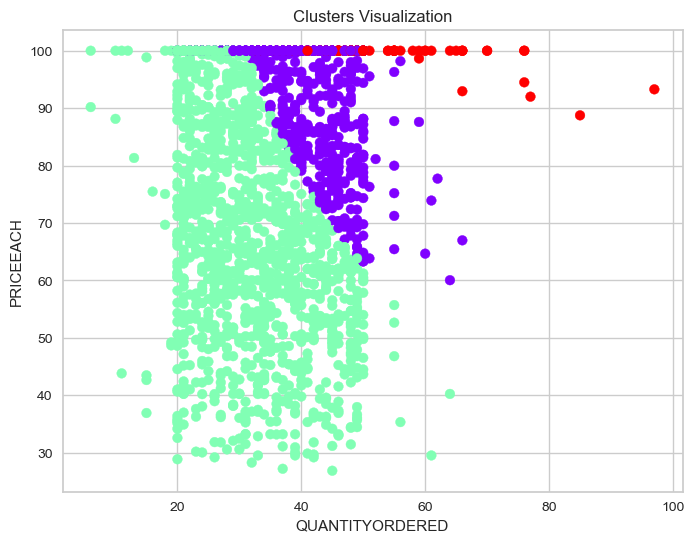

[1 1 0 ... 0 1 1]


In [56]:
y_kmeans = kmeanModel.fit_predict(df)

# Optional: visualize first two features
plt.figure(figsize=(8,6))
plt.scatter(df.iloc[:, 0], df.iloc[:, 1], c=y_kmeans, cmap='rainbow')
plt.title("Clusters Visualization")
plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])
plt.show()

print(y_kmeans)


In [58]:
plt.figure(figsize=(30, 26))

<Figure size 3000x2600 with 0 Axes>

<Figure size 3000x2600 with 0 Axes>

<Axes: >

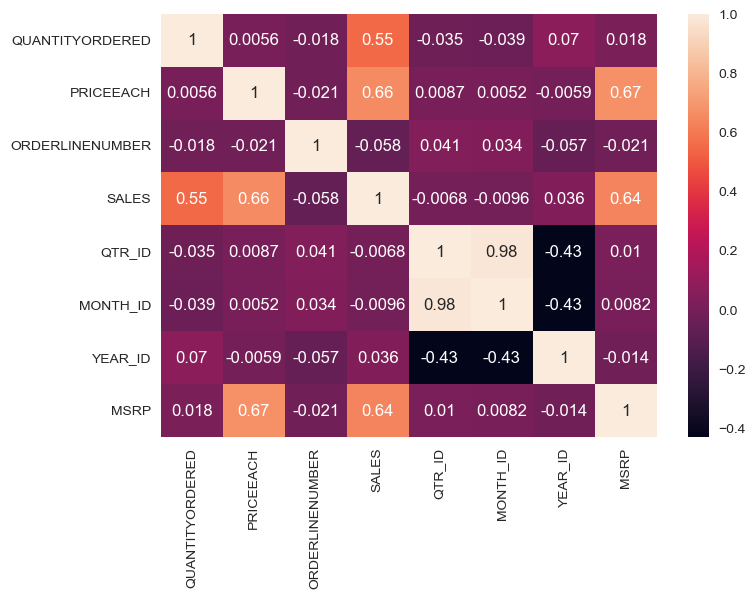

In [60]:
sns.heatmap(df.corr(), annot=True)

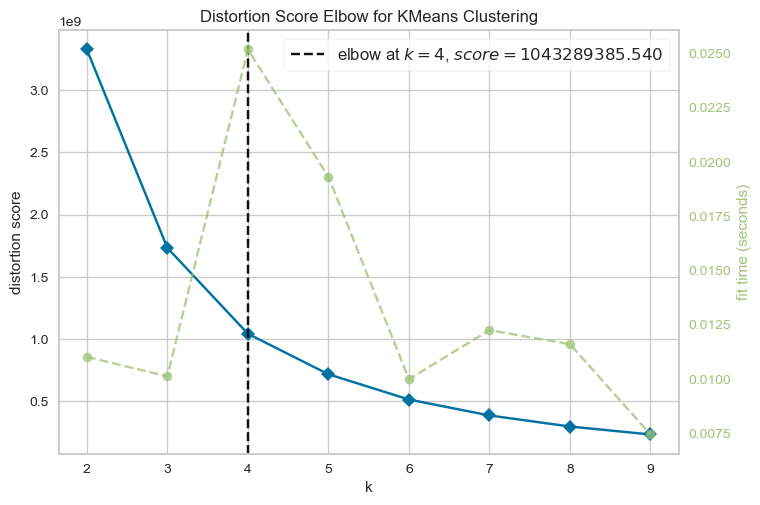

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [62]:
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer
import pandas as pd

# 1️⃣ Convert all columns to numeric if possible
df_numeric = df.select_dtypes(include=['number']).copy()

# If you have categorical columns (like 'Gender' or 'Date'), encode or drop them:
# Example: df_numeric = df.copy()
# df_numeric['Gender'] = LabelEncoder().fit_transform(df['Gender'])
# df_numeric = df_numeric.drop(columns=['Date'])

# 2️⃣ Create the KMeans model
model = KMeans(random_state=42)

# 3️⃣ Create the visualizer
visualizer = KElbowVisualizer(model, k=(2,10))

# 4️⃣ Fit the visualizer
visualizer.fit(df_numeric)  # NOT the original df if it contains strings/dates

# 5️⃣ Show the elbow curve
visualizer.show()


In [63]:
df.head()

,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,QTR_ID,MONTH_ID,YEAR_ID,MSRP
0,30,95.70,2,2871.00,1,2,2003,95
1,34,81.35,5,2765.90,2,5,2003,95
2,41,94.74,2,3884.34,3,7,2003,95
3,45,83.26,6,3746.70,3,8,2003,95
4,49,100.00,14,5205.27,4,10,2003,95


In [66]:
df_scaled = Normalizer(df)

In [68]:
from sklearn.preprocessing import StandardScaler

# Select only numeric columns (drop dates, strings)
df_num = df.select_dtypes(include=['number'])

# Scale numeric data
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_num)

# Convert back to DataFrame
df_x = pd.DataFrame(df_scaled, columns=df_num.columns)

df_x.head()


,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,QTR_ID,MONTH_ID,YEAR_ID,MSRP
0,-0.522891,0.596978,-1.057059,-0.370825,-1.427039,-1.392909,-1.16517,-0.142246
1,-0.112201,-0.114450,-0.347015,-0.427897,-0.596243,-0.572337,-1.16517,-0.142246
2,0.606505,0.549384,-1.057059,0.179443,0.234553,-0.025289,-1.16517,-0.142246
3,1.017195,-0.019759,-0.110334,0.104701,0.234553,0.248235,-1.16517,-0.142246
4,1.427884,0.810158,1.783116,0.896740,1.065350,0.795284,-1.16517,-0.142246
